# 1-Lipschitz encoding Setup

## Ground truths

In [43]:
import torch

def square(x, y, r):
    dx = x.abs() - r
    dy = y.abs() - r
    external_dist = torch.sqrt(dx.clamp(min=0.0)**2 + dy.clamp(min=0.0)**2)
    internal_dist = torch.minimum(torch.maximum(dx, dy), torch.zeros_like(dx))
    return external_dist + internal_dist

def circle(x, y, r):
    return torch.sqrt(x**2 + y**2) - r

def sdRhombus(x, y, size):
    px = x.abs()
    py = y.abs()
    if isinstance(size, (int, float)):
        size = (size, size * 1.5)
    wb, hb = size
    h = ((wb - 2.0 * px) * wb - (hb - 2.0 * py) * hb) / (wb**2 + hb**2)
    h = h.clamp(-1.0, 1.0)
    dx = px - 0.5 * wb * (1.0 - h)
    dy = py - 0.5 * hb * (1.0 + h)
    d = torch.sqrt(dx**2 + dy**2) * torch.sign(dx + dy)
    return d

def sdHexagon(x, y, r):
    kx, ky, kz = -0.866025404, 0.5, 0.577350269
    px = x.abs()
    py = y.abs()
    dot_kp = kx * px + ky * py
    sc = 2.0 * dot_kp.clamp(max=0.0)
    px = px - sc * kx
    py = py - sc * ky
    px = px - px.clamp(-kz * r, kz * r)
    py = py - r
    return torch.sqrt(px**2 + py**2) * torch.sign(py)

## Visualization


In [44]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_comparison(models=None, sdf_funcs=None, grid_res=200):
    """
    models    : liste de tuples (model, name), ou None
    sdf_funcs : liste de tuples (callable(x_t, y_t) -> tensor, name), ou None
    """
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    eps = 1e-5
    gridx = torch.linspace(-2 + eps, 2 - eps, grid_res)
    gridy = torch.linspace(-2 + eps, 2 - eps, grid_res)
    X_mesh, Y_mesh = torch.meshgrid(gridx, gridy, indexing='ij')
    input_pts = torch.stack([X_mesh.flatten(), Y_mesh.flatten()], dim=1).to(device)
    xn = X_mesh.cpu().numpy()
    yn = Y_mesh.cpu().numpy()
    spacing = (gridx[1] - gridx[0]).item()

    models     = models     or []
    sdf_funcs  = sdf_funcs  or []

    def compute_Z(Z_flat):
        Z = Z_flat.reshape(grid_res, grid_res).cpu().numpy()
        dZdx, dZdy = np.gradient(Z, spacing)
        mag = np.sqrt(dZdx**2 + dZdy**2)
        return Z, mag

    def plot_row(ax_sdf, ax_grad, Z, mag, title):
        max_abs = np.max(np.abs(Z))
        cp = ax_sdf.contourf(xn, yn, Z, levels=100, cmap='RdBu',
                             vmin=-max_abs, vmax=max_abs)
        ax_sdf.contour(xn, yn, Z, levels=[0], colors='white', linewidths=2)
        ax_sdf.set_title(f"{title} — SDF", fontweight='bold')
        ax_sdf.set_aspect('equal')
        ax_sdf.set_xlim(-2, 2)
        ax_sdf.set_ylim(-2, 2)
        plt.colorbar(cp, ax=ax_sdf, label='Distance')

        im = ax_grad.imshow(mag.T, extent=[-2, 2, -2, 2],
                            origin='lower', cmap='viridis', vmin=0)
        ax_grad.set_title(f"{title} — ‖∇f‖", fontweight='bold')
        ax_grad.set_aspect('equal')
        plt.colorbar(im, ax=ax_grad, label='Magnitude')

    n_rows = len(models) + len(sdf_funcs)
    assert n_rows > 0, "Fournir au moins un modèle ou une GT."

    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 5 * n_rows),
                             constrained_layout=True)
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    row = 0

    for model, name in models:
        model.eval()
        with torch.no_grad():
            Z_flat = model(input_pts)
        Z, mag = compute_Z(Z_flat)
        plot_row(axes[row, 0], axes[row, 1], Z, mag, name)
        row += 1

    x_t = input_pts[:, 0]
    y_t = input_pts[:, 1]
    for sdf_func, name in sdf_funcs:
        with torch.no_grad():
            Z_flat = sdf_func(x_t, y_t)
        Z, mag = compute_Z(Z_flat)
        plot_row(axes[row, 0], axes[row, 1], Z, mag, f"GT — {name}")
        row += 1

    plt.suptitle("Comparaison des modèles", fontsize=16, fontweight='bold')
    plt.show()

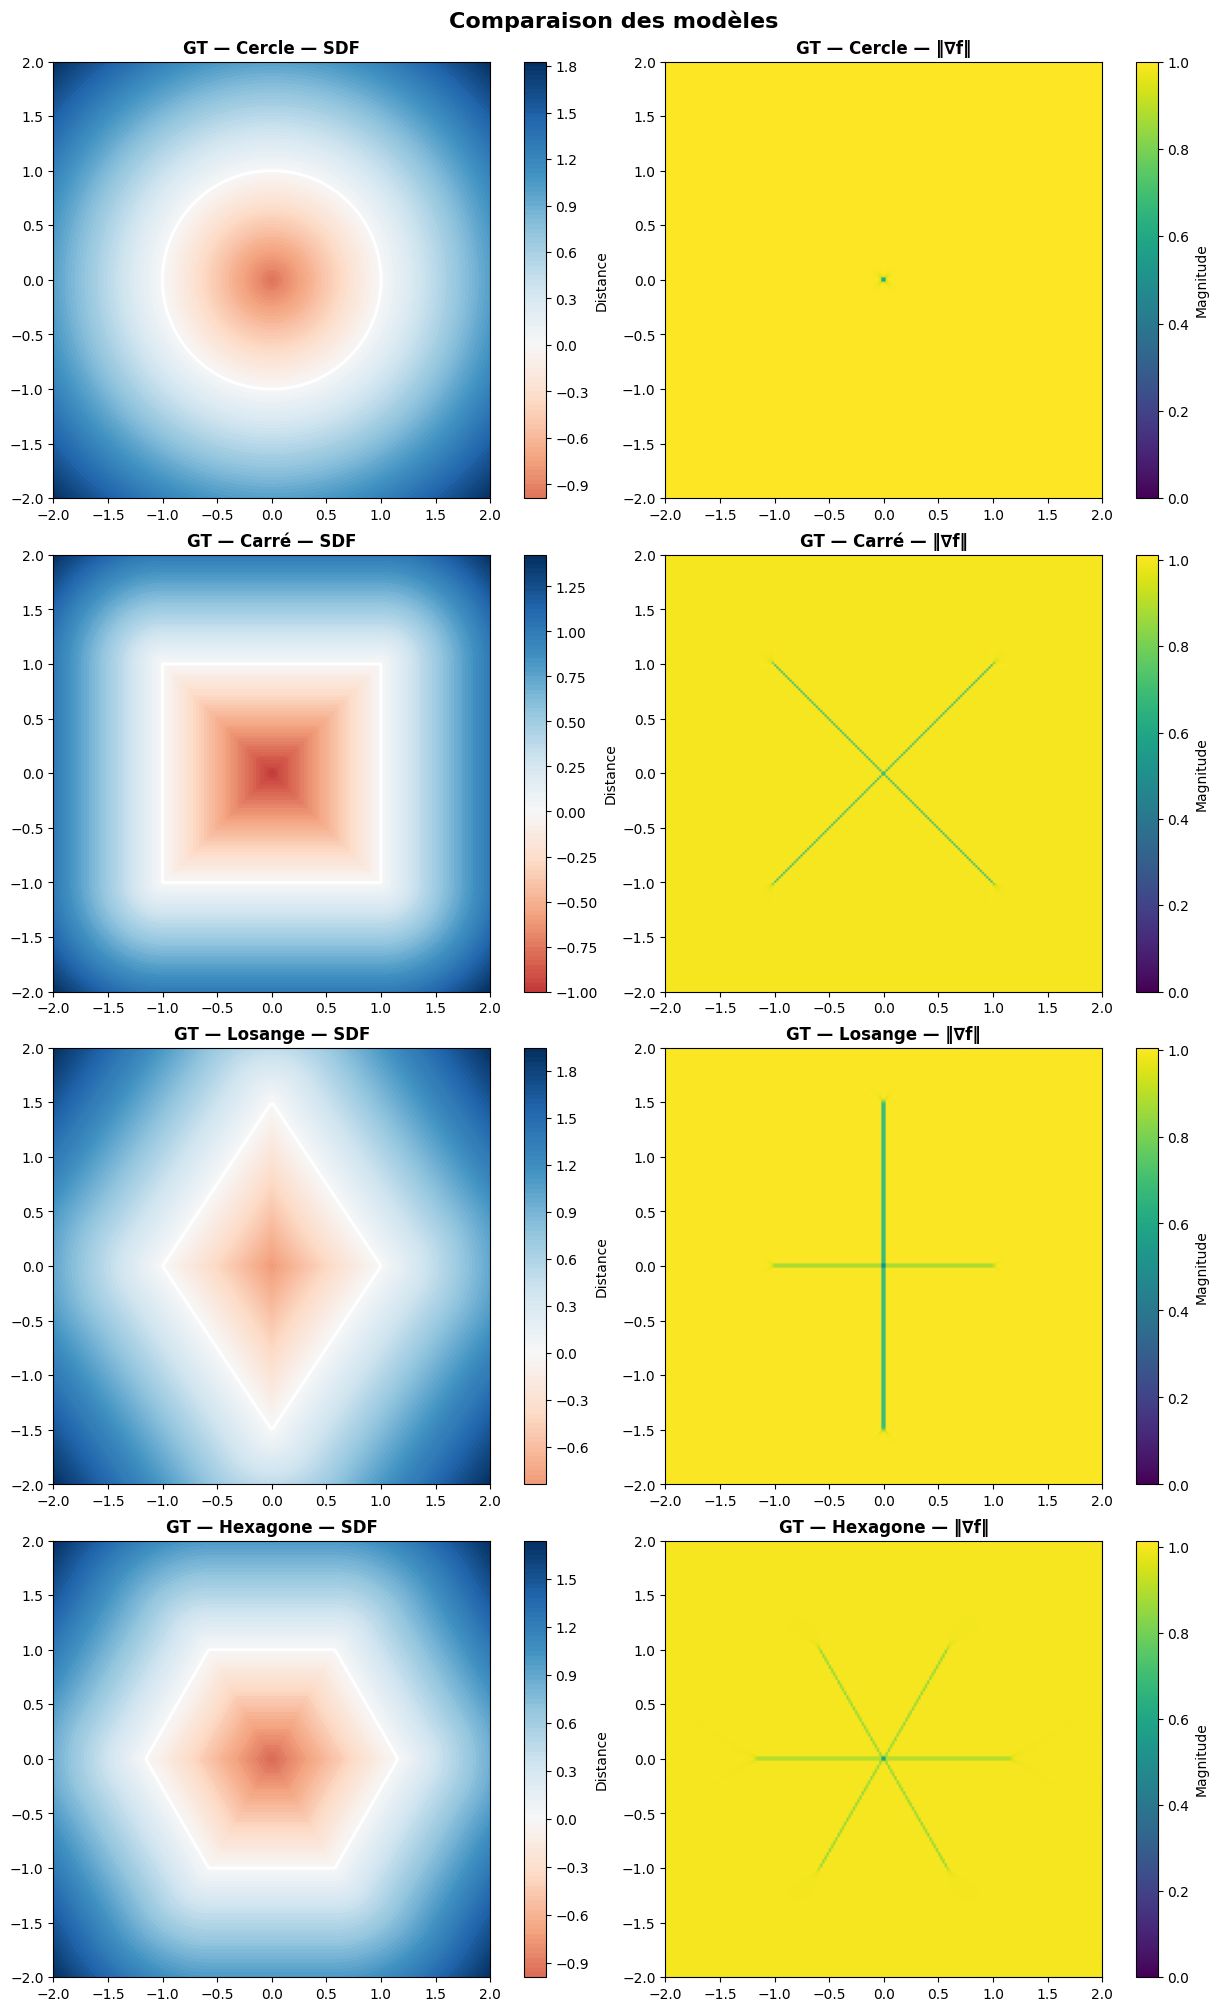

In [45]:
visualize_comparison(
    sdf_funcs=[
        (lambda x, y: circle(x, y, 1),   "Cercle"),
        (lambda x, y: square(x, y, 1),   "Carré"),
        (lambda x, y: sdRhombus(x, y, 1), "Losange"),
        (lambda x, y: sdHexagon(x, y, 1), "Hexagone"),
    ]
)

## Lipschitz Layers and loss

In [64]:
import torch
import torch.nn as nn
class SLLLayer(nn.Module):
    def __init__(self, k, scale=1.0):
        super().__init__()
        self.scale = scale
        self.W = nn.Parameter(torch.randn(k, k) * (1.0 / k**0.5))
        self.b = nn.Parameter(torch.zeros(k))
        self.q = nn.Parameter(torch.zeros(k))

    def forward(self, x):
        WtW = self.W.T @ self.W
        q = self.q
        T = torch.abs(WtW * torch.exp(q[None, :] - q[:, None])).sum(dim=1)
        T_inv = 1.0 / (T + 1e-8)
        h = torch.relu(x @ self.W + self.b)
        return (x - 2.0 * (h * T_inv) @ self.W.T) * self.scale


class LipschitzSDF(nn.Module):
    def __init__(self, k=128, n_layers=20):
        super().__init__()
        self.k = k
        self.sll = nn.Sequential(*[SLLLayer(k) for _ in range(n_layers)])
        self.w_out = nn.Parameter(torch.randn(k) / k**0.5)
        self.b_out = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        # zero-pad l'entrée (n=2) vers la dimension k
        x = torch.nn.functional.pad(x, (0, self.k - x.shape[-1]))
        x = self.sll(x)
        # 1-Lipschitz : w^T x / ||w||_2 + b
        return (x @ self.w_out) / self.w_out.norm() + self.b_out

In [47]:
import torch
import torch.nn.functional as F

class LossHKR:
    """ Hinge Kantorovitch-Rubinstein loss"""

    def __init__(self, margin, lbda):
        self.margin = margin  # must be small but not too small.
        self.lbda   = lbda  # must be high.

    def __call__(self, y):
        """
        Args:
            y: vector of predictions.
        """
        return  F.relu(self.margin - y) + (1./self.lbda) * torch.mean(-y)
    
def vector_alignment_loss(y, target):
    return (1-F.cosine_similarity(y, target, dim = 1)*2).mean()


## Param encoding

In [68]:
import torch
import torch.nn as nn

class LipschitzParametricEncoding(nn.Module):
    def __init__(self, resolution=32, feature_dim=8, domain=(-2, 2), constant_majoration=True,project_all = False):
        super().__init__()
        self.resolution = resolution
        self.feature_dim = feature_dim
        self.domain = domain
        self.dx = (domain[1] - domain[0]) / (resolution - 1)
        self.table_size = resolution * resolution
        self.table = nn.Parameter(
            torch.empty(feature_dim,self.table_size).uniform_(-1e-4, 1e-4)
        )
        self.constant_majoration = constant_majoration
        self.majoration_treshold = self.dx / np.sqrt(3)
        self.project_all = project_all

    def L(self, x):
        indices = self.get_indices(x)
        Aij = self.Aij(indices)
        grad_Dij = self.grad_Dij(x, indices[0])
        Aij_gradDij = torch.bmm(Aij, grad_Dij)
        Lij = Aij_gradDij
        return torch.linalg.matrix_norm(Lij, ord=2)

    def grad_Dij(self, x, xij):
        alpha = x[:, 1] - xij[:, 1]
        beta  = x[:, 0] - xij[:, 0]
        # Batched stack returning (N, 4, 2)
        grad = torch.stack([
            torch.stack([alpha - self.dx, beta - self.dx], dim=-1),
            torch.stack([self.dx - alpha, -beta], dim=-1),
            torch.stack([-alpha, self.dx - beta], dim=-1),
            torch.stack([alpha, beta], dim=-1)
        ], dim=1) / (self.dx**2)
        return grad
    

    

    def hash(self, index):
        index = torch.round(self.normalize(index)).long()  
        return index[:, 0] * self.resolution + index[:, 1]

    def hash_indices(self,indices):
        return [self.hash(i) for i in indices]
    
    def normalize(self, x):
        lo, hi = self.domain
        xr = (x - lo)/(hi - lo) * (self.resolution - 1)
        return xr
    
    def get_indices(self, x):
        lo = self.domain[0]
        xr = self.normalize(x)                                   
        i0 = torch.floor(xr).long().clamp(0, self.resolution - 2)
        xij = lo + i0.float() * self.dx
        xip1j = xij + torch.tensor([1, 0], device=x.device)
        xip1j   = xij + torch.tensor([self.dx, 0],       device=x.device)
        xijp1   = xij + torch.tensor([0,       self.dx], device=x.device)
        xip1jp1 = xij + torch.tensor([self.dx, self.dx], device=x.device)
        return (xij, xip1j, xijp1, xip1jp1)
    
    def D(self, x, xij):
        Dx = (x[:, 0] - xij[:, 0])/self.dx
        Dy = (x[:, 1] - xij[:, 1])/self.dx
        # Batched stack returning (N, 4, 1)
        return torch.stack([(1-Dx)*(1-Dy), (Dx)*(1-Dy), (1-Dx)*(Dy), (Dx)*(Dy)], dim=-1).unsqueeze(-1)
    
    def Aij(self, indices):
        corners = [self.table[:, self.hash(i)].T for i in indices]  # (N, F) chacun
        return torch.stack(corners, dim=-1)  # (N, F, 4)

    def forward(self, x):
        indices = self.get_indices(x)
        Aij = self.Aij(indices)
        Dij = self.D(x, indices[0])

        # (N, F, 4) @ (N, 4, 1) -> (N, F, 1) -> (N, F)
        wf = torch.bmm(Aij, Dij).squeeze(-1)
        return wf
    
    def project_sub_matrix(self, x,treshold):
        indices = self.get_indices(x)
        Aij = self.Aij(indices)
        hashes = self.hash_indices(indices)


        if isinstance(treshold, torch.Tensor) and treshold.dim() > 0:
            treshold = treshold.unsqueeze(-1)  # (N,) → (N, 1) pour broadcaster avec S (N, 4)

        with torch.no_grad():
            U, S, Vt = torch.linalg.svd(Aij, full_matrices=False)
            S_clipped = torch.clamp(S, max=treshold)

            Aij_projected = U @ torch.diag_embed(S_clipped) @ Vt  # (N, F, 4)

            for c in range(4):
                self.table[:, hashes[c]] = Aij_projected[:, :, c].T


    def project_all_cells(self,treshold):
        with torch.no_grad():
            for i in range(self.resolution - 1):
                for j in range(self.resolution - 1):
                    h00 = i * self.resolution + j
                    h10 = (i + 1) * self.resolution + j
                    h01 = i * self.resolution + (j + 1)
                    h11 = (i + 1) * self.resolution + (j + 1)

                    Aij = torch.stack([
                        self.table[:, h00],
                        self.table[:, h10],
                        self.table[:, h01],
                        self.table[:, h11],
                    ], dim=1)  # (F, 4)

                    U, S, Vt = torch.linalg.svd(Aij, full_matrices=False)
                    S_clipped = torch.clamp(S, max=treshold)
                    Aij_proj = U @ torch.diag(S_clipped) @ Vt  # (F, 4)

                    self.table[:, h00] = Aij_proj[:, 0]
                    self.table[:, h10] = Aij_proj[:, 1]
                    self.table[:, h01] = Aij_proj[:, 2]
                    self.table[:, h11] = Aij_proj[:, 3]

    def project_majoration(self, x):
        if self.constant_majoration:
            threshold = self.majoration_treshold 
        else:
            if self.project_all:
                raise ValueError("project_all=True nécessite constant_majoration=True")
            grad_norm = torch.linalg.matrix_norm(
                self.grad_Dij(x, self.get_indices(x)[0]), ord=2
            )
            threshold = 1.0 / grad_norm.clamp(min=1e-8) 
        
        if self.project_all:
            self.project_all_cells(threshold)
        else:
            self.project_sub_matrix(x, threshold)

class LipschitzParam(nn.Module):
    def __init__(self, resolution=32, feature_dim=8, k=128, n_layers=20,
                 add_positions=False, project_all=False, constant_majoration=True,divide=True, sll_divide = False):
        super().__init__()
        self.add_positions = add_positions
        self.enc    = LipschitzParametricEncoding(resolution, feature_dim,
                                                  project_all=project_all, constant_majoration=constant_majoration)
        self.in_dim = feature_dim + (2 if add_positions else 0)
        self.k      = k
        last = SLLLayer(k, scale=1.0 / 2**0.5) if sll_divide else SLLLayer(k)
        rest  = [SLLLayer(k) for _ in range(n_layers - 1)]
        self.sll = nn.Sequential(*rest, last)
        self.w_out  = nn.Parameter(torch.randn(k) / k**0.5)
        self.b_out  = nn.Parameter(torch.zeros(1))
        self.divide = divide
        
    def L_pre(self,x):
        return torch.sqrt(self.enc.L(x)**2 + 1) if self.add_positions else self.enc.L(x)

    def forward(self, x):
        feat = self.enc(x)                              # (N, F)
        if self.add_positions:
            feat = torch.cat([feat, x], dim=-1)         # (N, F+2)
        feat = F.pad(feat, (0, self.k - self.in_dim)) 
        feat = self.sll(feat)                           # (N, k)
        scale = self.w_out.norm() * (2**0.5 if self.divide and self.add_positions else 1.0)
        return (feat @ self.w_out) / scale + self.b_out 

In [49]:
def train_Lipschitz_param(model, sdf_func, nb_samples, lr, nb_epochs,
                   m=0.01, lambda_schedule=None, parallel=False, encoding = True, majoration=False):
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    if parallel and torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for training.")
        model = nn.DataParallel(model)
        enc = model.module.enc if encoding else None
    else:
        enc = model.enc if encoding else None
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if lambda_schedule is None:
        lambda_schedule = {i : 10*(i-1) for i in range(nb_epochs//100)}
    loss_fn = LossHKR(margin=m, lbda=1.0)
    history = []

    for epoch in range(nb_epochs):
        if epoch in lambda_schedule:
            loss_fn.lbda = lambda_schedule[epoch] * 2
            print(f"  → λ = {loss_fn.lbda}")

        x = (torch.rand(nb_samples, 2, device=device) * 4) - 2

        with torch.no_grad():
            sdf_vals = sdf_func(x[:, 0], x[:, 1])   # ← torch direct, plus de numpy

        y = torch.where(sdf_vals >= 0,
                        torch.ones_like(sdf_vals),
                        -torch.ones_like(sdf_vals))

        pred = model(x).squeeze()
        loss = loss_fn(y * pred).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if majoration:
            enc.project_majoration(x)

        history.append(loss.item())
        if epoch % (nb_epochs // 10) == 0:
            if encoding:
                with torch.no_grad():
                    enc_max_L = enc.L(x).max().item()
                    pre_max_L = model.module.L_pre(x).max().item()
                print(f"Epoch {epoch:5d} | loss={loss.item():.5f} | Max Batch L_enc={enc_max_L:.4f} | Max Batch L_pre = {pre_max_L:.4f} | Total L (theoretical) : {pre_max_L/np.sqrt(2):.4f}")
            else :
                print(f"Epoch {epoch:5d} | loss={loss.item():.5f}")

    return model, history

# Complete Comparaison

## Only on square

### Simple SLL

In [13]:
sll_simple, hist = train_Lipschitz_param(
    LipschitzSDF(
        k=128,
        n_layers=20,
    ),
    lambda x, y: square(x, y, 1.0), 
    100000, 
    1e-3,     
    nb_epochs=8000,
    m=0.01,                
    lambda_schedule={
    0:    10,
    500:  30,
    1000: 60,
    2000: 100,
    },
    parallel=True,
    majoration=False,
    encoding = False
)

Using 2 GPUs for training.
  → λ = 20
Epoch     0 | loss=0.01866
  → λ = 60
Epoch   800 | loss=-0.00849
  → λ = 120
Epoch  1600 | loss=-0.00426
  → λ = 200
Epoch  2400 | loss=-0.00254
Epoch  3200 | loss=-0.00256
Epoch  4000 | loss=-0.00256
Epoch  4800 | loss=-0.00258
Epoch  5600 | loss=-0.00260
Epoch  6400 | loss=-0.00258
Epoch  7200 | loss=-0.00259


### Simple Encoding

In [51]:
mlp_grid_square, hist = train_Lipschitz_param(
    LipschitzParam(
        resolution=32,
        feature_dim=8,
        k=128,
        n_layers=20,
        add_positions=False,
            ),
    lambda x, y: square(x, y, 1.0),
    10000, 
    1e-3,     
    nb_epochs=8000,
    m=0.005,                
    lambda_schedule={
        0:    10,
        500:  30,
        1000: 60,
        2000: 100,
        3000: 200,
        4000: 400,
        5000: 800,
    },
    parallel=True,
    majoration=False
    )

Using 2 GPUs for training.
  → λ = 20
Epoch     0 | loss=0.00500 | Max Batch L_enc=0.0522 | Max Batch L_pre = 0.0522 | Total L (theoretical) : 0.0369
  → λ = 60
Epoch   800 | loss=-0.03361 | Max Batch L_enc=27.0303 | Max Batch L_pre = 27.0303 | Total L (theoretical) : 19.1133
  → λ = 120
Epoch  1600 | loss=-0.02419 | Max Batch L_enc=38.7454 | Max Batch L_pre = 38.7454 | Total L (theoretical) : 27.3971
  → λ = 200
Epoch  2400 | loss=-0.01879 | Max Batch L_enc=44.8127 | Max Batch L_pre = 44.8127 | Total L (theoretical) : 31.6874
  → λ = 400
Epoch  3200 | loss=-0.01144 | Max Batch L_enc=53.6897 | Max Batch L_pre = 53.6897 | Total L (theoretical) : 37.9644
  → λ = 800
Epoch  4000 | loss=-0.00631 | Max Batch L_enc=57.3482 | Max Batch L_pre = 57.3482 | Total L (theoretical) : 40.5513
Epoch  4800 | loss=-0.00673 | Max Batch L_enc=60.9097 | Max Batch L_pre = 60.9097 | Total L (theoretical) : 43.0697
  → λ = 1600
Epoch  5600 | loss=-0.00383 | Max Batch L_enc=59.0514 | Max Batch L_pre = 59.0514 

### Encoding + constraint

In [53]:
mlp_grid_square_majoration, hist = train_Lipschitz_param(
    LipschitzParam(
        resolution=32,
        feature_dim=8,
        k=128,
        n_layers=20,
        add_positions=False,
            ),
    lambda x, y: square(x, y, 1.0),
    10000, 
    1e-3,     
    nb_epochs=8000,
    m=0.005,                
    lambda_schedule={
        0:    10,
        500:  30,
        1000: 60,
        2000: 100,
        3000: 200,
        4000: 400,
        5000: 800,
    },
    parallel=True,
    majoration=True
    )

Using 2 GPUs for training.
  → λ = 20
Epoch     0 | loss=0.00500 | Max Batch L_enc=0.0495 | Max Batch L_pre = 0.0495 | Total L (theoretical) : 0.0350
  → λ = 60
Epoch   800 | loss=-0.00078 | Max Batch L_enc=1.0266 | Max Batch L_pre = 1.0266 | Total L (theoretical) : 0.7259
  → λ = 120
Epoch  1600 | loss=-0.00038 | Max Batch L_enc=1.1445 | Max Batch L_pre = 1.1445 | Total L (theoretical) : 0.8093
  → λ = 200
Epoch  2400 | loss=-0.00022 | Max Batch L_enc=1.1181 | Max Batch L_pre = 1.1181 | Total L (theoretical) : 0.7906
  → λ = 400
Epoch  3200 | loss=-0.00009 | Max Batch L_enc=1.1416 | Max Batch L_pre = 1.1416 | Total L (theoretical) : 0.8072
  → λ = 800
Epoch  4000 | loss=-0.00004 | Max Batch L_enc=1.1108 | Max Batch L_pre = 1.1108 | Total L (theoretical) : 0.7854
Epoch  4800 | loss=-0.00004 | Max Batch L_enc=1.1007 | Max Batch L_pre = 1.1007 | Total L (theoretical) : 0.7783
  → λ = 1600
Epoch  5600 | loss=0.00000 | Max Batch L_enc=1.0966 | Max Batch L_pre = 1.0966 | Total L (theoretica

### Enconding + constraint + XY

- With maximized constant

In [17]:
mlp_grid_square_majoration_XY, hist = train_Lipschitz_param(
    LipschitzParam(
        resolution=64,
        feature_dim=16,
        k=128,
        n_layers=20,
        add_positions=True,
        project_all=False,
        constant_majoration=True
    ),
    lambda x, y: square(x, y, 1.0),
    nb_samples=100_000,
    lr=1e-3,
    nb_epochs=8000,
    m=0.01, 
    parallel=True,
    majoration=True,
    lambda_schedule={
        0:    10,
        500:  30,
        1000: 60,
        2000: 100,
        3000: 200,
        4000: 400,
        5000: 800,
    }
)

Using 2 GPUs for training.
  → λ = 20
Epoch     0 | loss=0.00943 | Max Batch L_enc=0.1594 | Max Batch L_pre = 1.0126 | Total L (theoretical) : 0.7160
  → λ = 60
Epoch   800 | loss=-0.00600 | Max Batch L_enc=1.1459 | Max Batch L_pre = 1.5209 | Total L (theoretical) : 1.0754
  → λ = 120
Epoch  1600 | loss=-0.00298 | Max Batch L_enc=1.1621 | Max Batch L_pre = 1.5331 | Total L (theoretical) : 1.0841
  → λ = 200
Epoch  2400 | loss=-0.00176 | Max Batch L_enc=1.1465 | Max Batch L_pre = 1.5213 | Total L (theoretical) : 1.0757
  → λ = 400
Epoch  3200 | loss=-0.00085 | Max Batch L_enc=1.1559 | Max Batch L_pre = 1.5285 | Total L (theoretical) : 1.0808
  → λ = 800
Epoch  4000 | loss=-0.00039 | Max Batch L_enc=1.1377 | Max Batch L_pre = 1.5147 | Total L (theoretical) : 1.0711
Epoch  4800 | loss=-0.00038 | Max Batch L_enc=1.1402 | Max Batch L_pre = 1.5166 | Total L (theoretical) : 1.0724
  → λ = 1600
Epoch  5600 | loss=-0.00016 | Max Batch L_enc=1.1343 | Max Batch L_pre = 1.5122 | Total L (theoretic

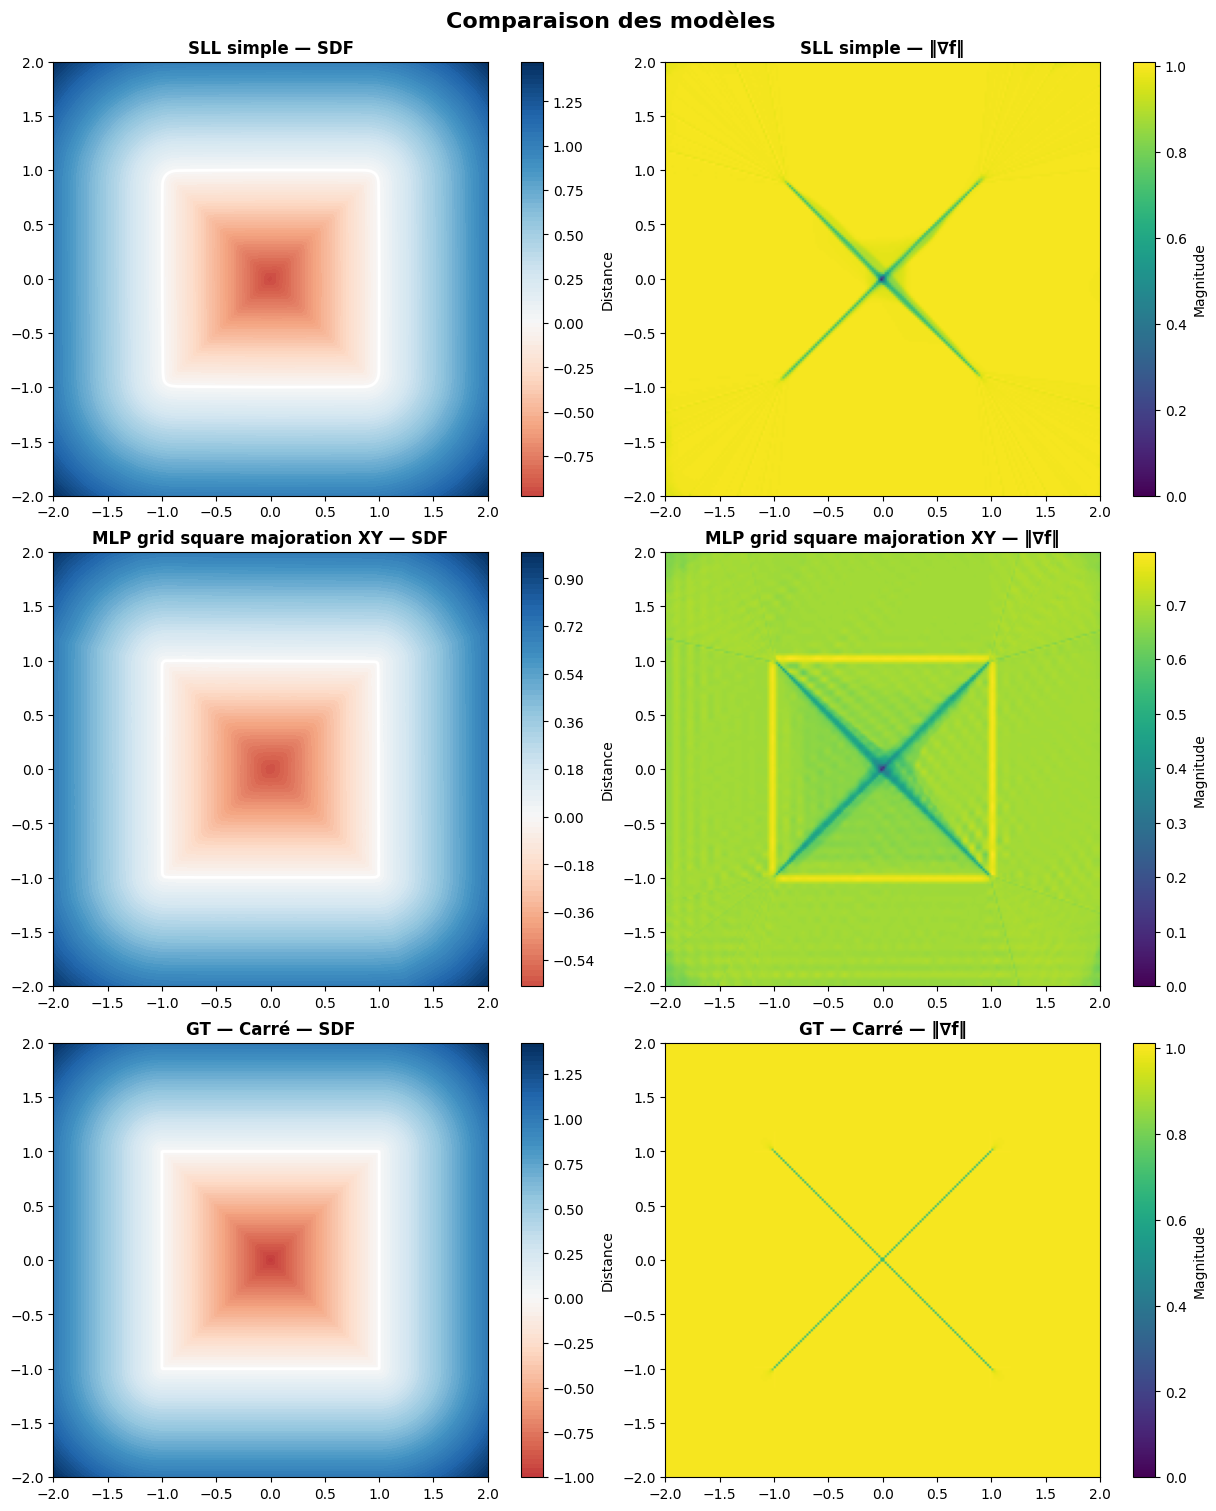

In [231]:
visualize_comparison(
    models=[
        (sll_simple, "SLL simple"),
        (mlp_grid_square_majoration_XY, "MLP grid square majoration XY"),
    ],
    sdf_funcs=[
        (lambda x, y: square(x, y, 1.0),   "Carré"),
    ]
)

- With computed norm for D

In [245]:
mlp_grid_square_XY_real_D, hist = train_Lipschitz_param(
    LipschitzParam(
        resolution=64,
        feature_dim=16,
        k=128,
        n_layers=20,
        add_positions=True,
        project_all=False,
        constant_majoration=False
    ),
    lambda x, y: square(x, y, 1.0),
    nb_samples=100_000,
    lr=1e-3,
    nb_epochs=8000,
    m=0.01, 
    parallel=True,
    majoration=True,
    lambda_schedule={
        0:    10,
        500:  30,
        1000: 60,
        2000: 100,
        3000: 200,
        4000: 400,
        5000: 800,
    }
)

Using 2 GPUs for training.
  → λ = 20
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Epoch     0 | loss=0.00476 | Max Batch L_enc=0.1692 | Max Batch L_pre = 1.0142 | Total L (theoretical) : 0.7172
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold: 0.0367, constant: 0.0367, Max dynamic: 0.0635
Min dynamic threshold:

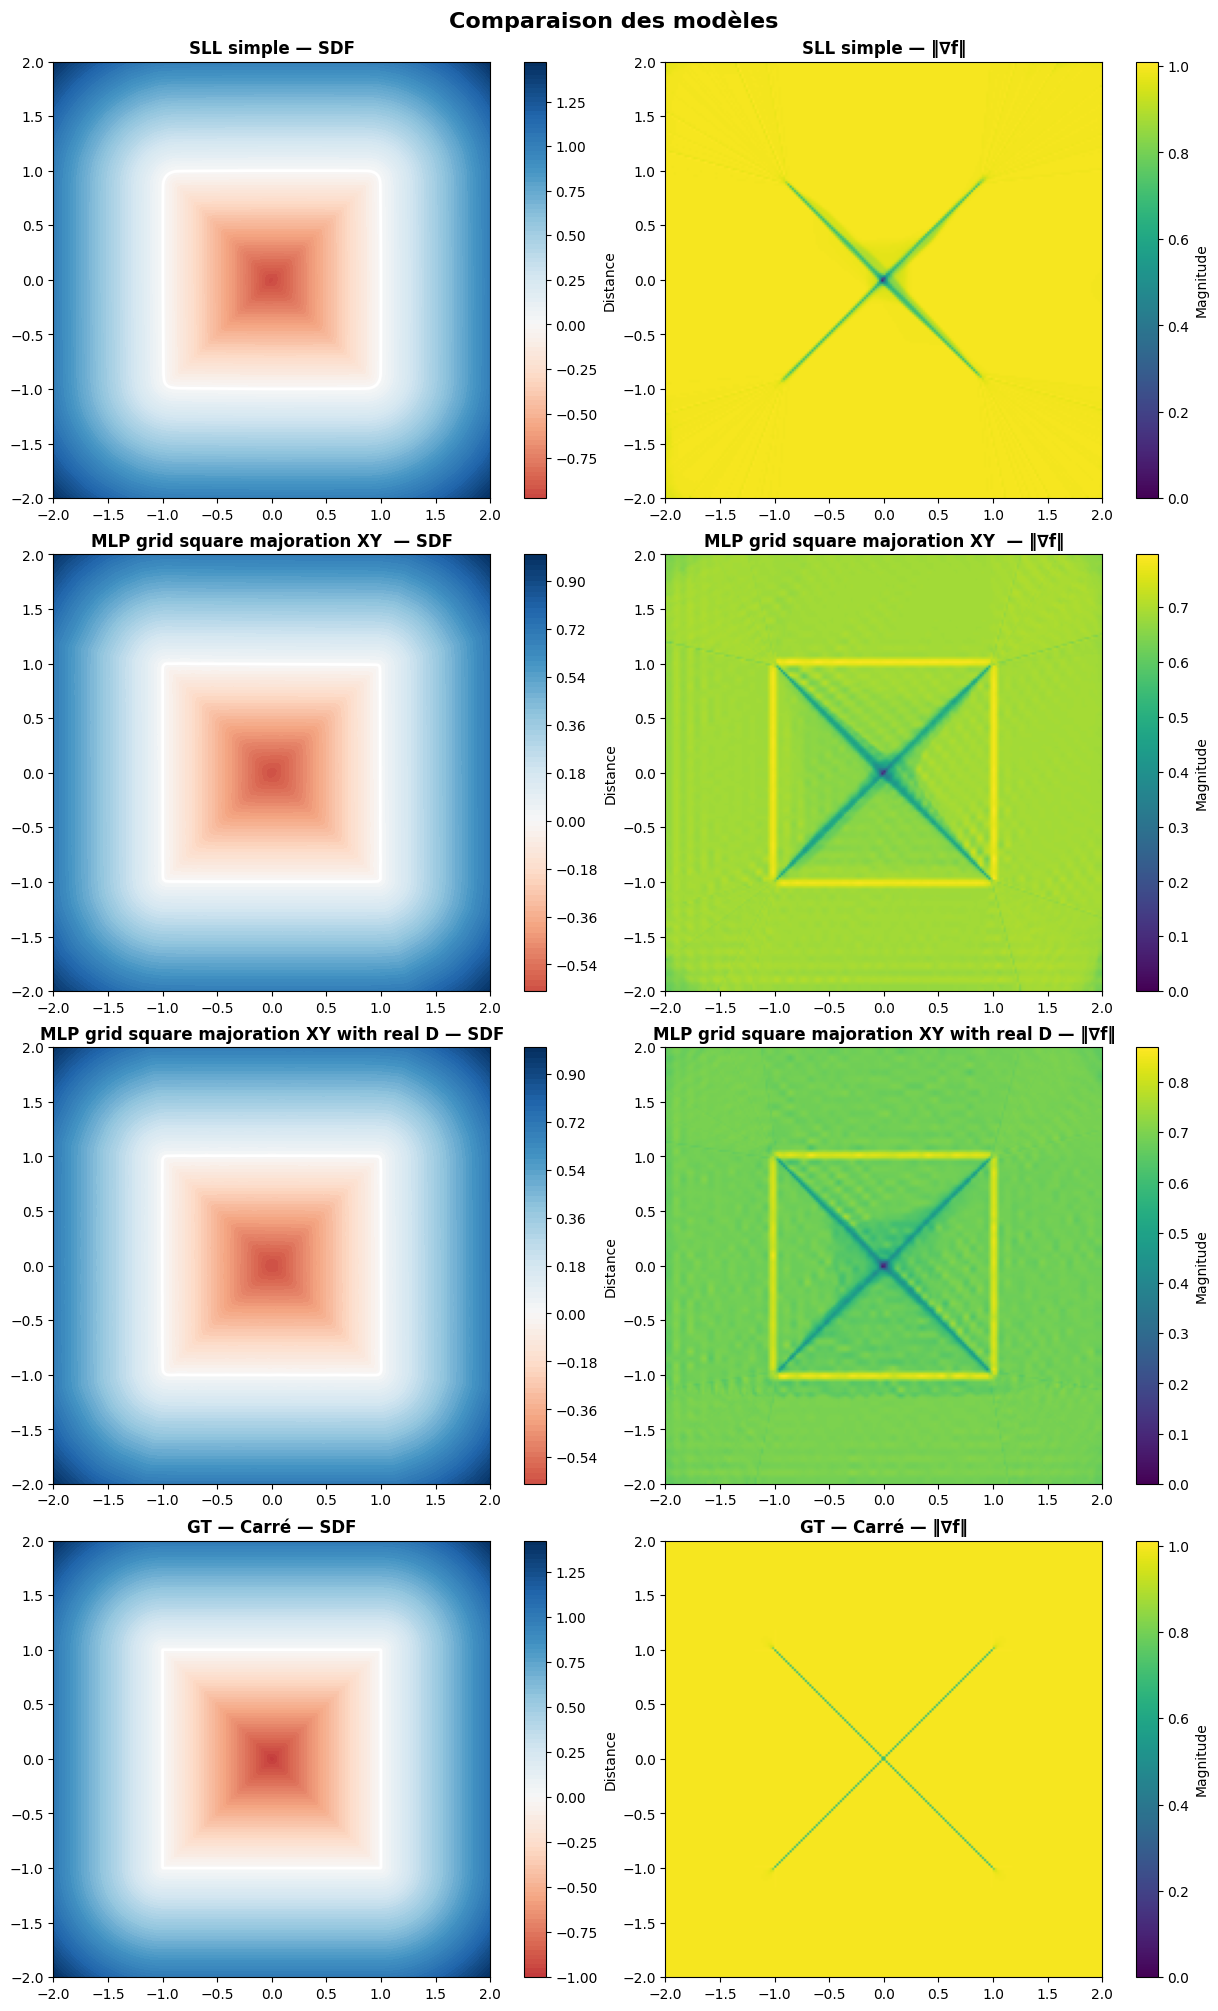

In [246]:
visualize_comparison(
    models=[
        (sll_simple, "SLL simple"),
        (mlp_grid_square_majoration_XY, "MLP grid square majoration XY "),
        (mlp_grid_square_XY_real_D, "MLP grid square majoration XY with real D"),
    ],
    sdf_funcs=[
        (lambda x, y: square(x, y, 1.0),   "Carré"),
    ]
)

- With projection on every cell (not just sub-matrix)

In [9]:
mlp_grid_square_proj_all, hist = train_Lipschitz_param(
    LipschitzParam(
        resolution=64,
        feature_dim=16,
        k=128,
        n_layers=20,
        add_positions=True,
        project_all=True,
        constant_majoration=True
    ),
    lambda x, y: square(x, y, 1.0),
    nb_samples=100_000,
    lr=1e-3,
    nb_epochs=8000,
    m=0.01, 
    parallel=True,
    majoration=True,
    lambda_schedule={
        0:    10,
        500:  30,
        1000: 60,
        2000: 100,
        3000: 200,
        4000: 400,
        5000: 800,
    }
)

Using 2 GPUs for training.
  → λ = 20
Epoch     0 | loss=0.01235 | Max Batch L_enc=0.1568 | Max Batch L_pre = 1.0122 | Total L (theoretical) : 0.7157
  → λ = 60
Epoch   800 | loss=-0.00594 | Max Batch L_enc=0.8954 | Max Batch L_pre = 1.3423 | Total L (theoretical) : 0.9491
  → λ = 120
Epoch  1600 | loss=-0.00299 | Max Batch L_enc=0.9287 | Max Batch L_pre = 1.3647 | Total L (theoretical) : 0.9650
  → λ = 200
Epoch  2400 | loss=-0.00177 | Max Batch L_enc=0.9324 | Max Batch L_pre = 1.3673 | Total L (theoretical) : 0.9668
  → λ = 400
Epoch  3200 | loss=-0.00085 | Max Batch L_enc=0.9525 | Max Batch L_pre = 1.3811 | Total L (theoretical) : 0.9766
  → λ = 800
Epoch  4000 | loss=-0.00039 | Max Batch L_enc=0.9503 | Max Batch L_pre = 1.3795 | Total L (theoretical) : 0.9755
Epoch  4800 | loss=-0.00038 | Max Batch L_enc=0.9498 | Max Batch L_pre = 1.3792 | Total L (theoretical) : 0.9752
  → λ = 1600
Epoch  5600 | loss=-0.00016 | Max Batch L_enc=0.9411 | Max Batch L_pre = 1.3732 | Total L (theoretic

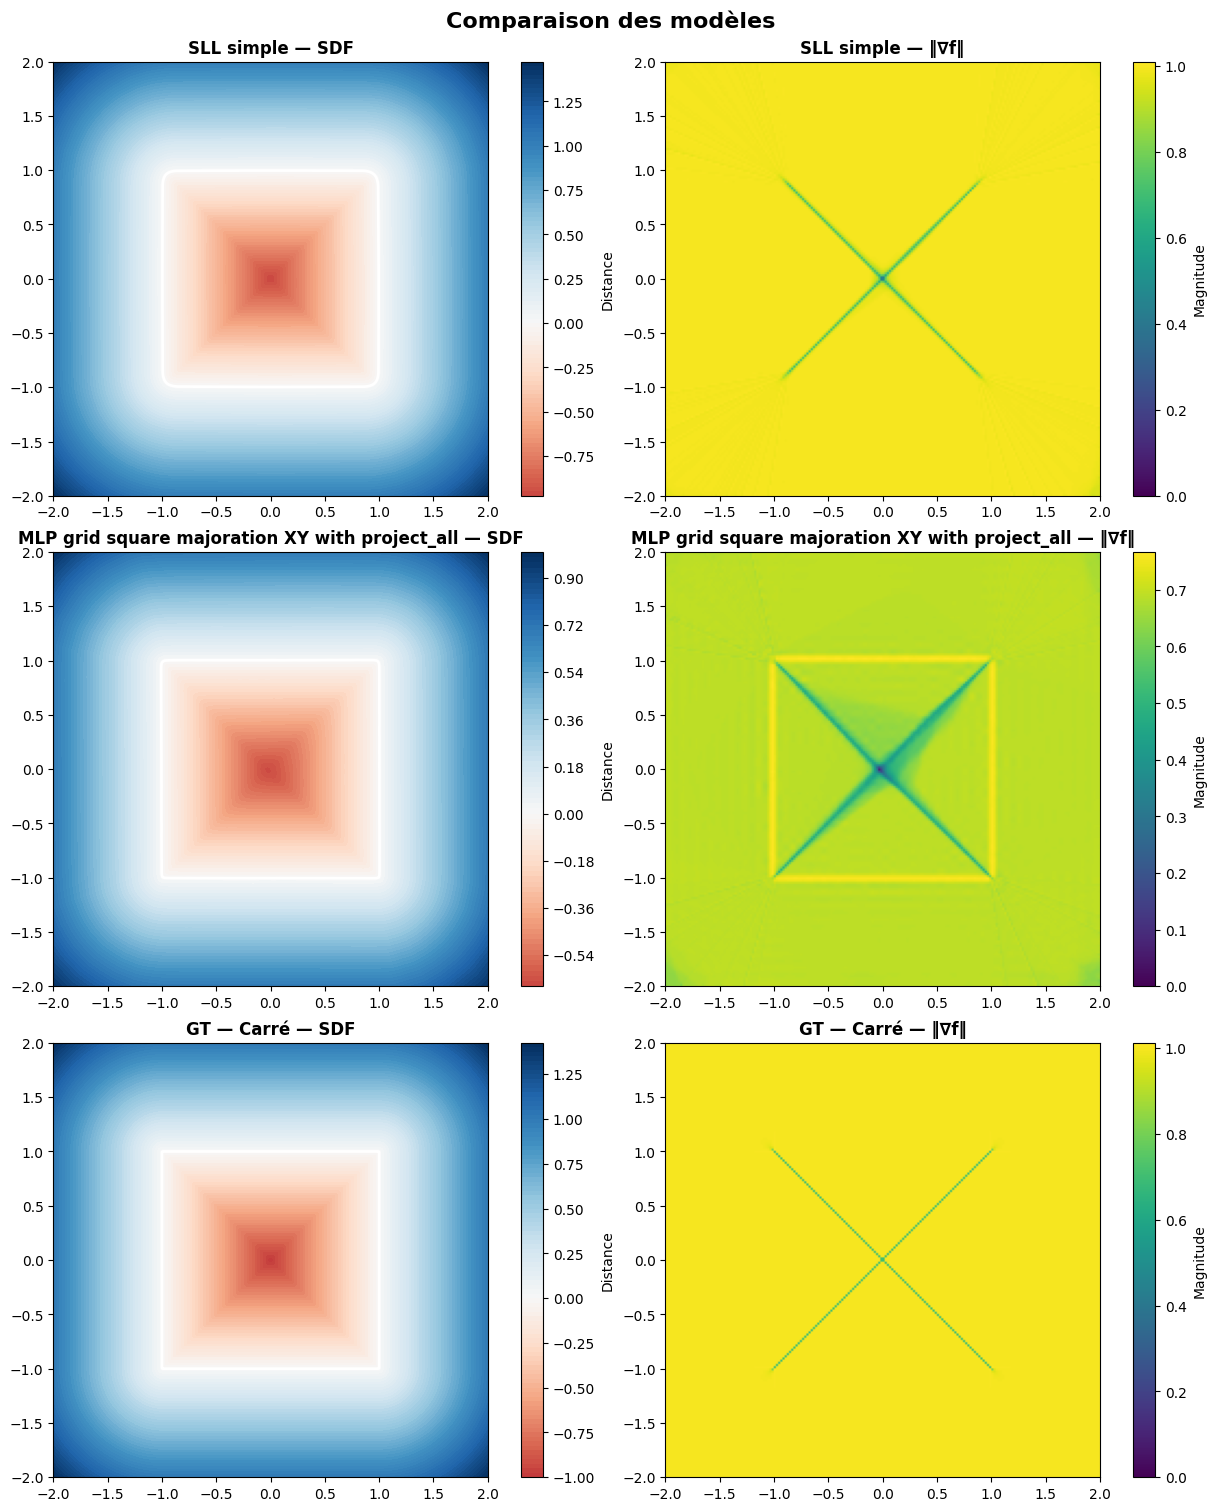

In [16]:
visualize_comparison(
    models=[
        (sll_simple, "SLL simple"),
        # (mlp_grid_square_majoration_XY, "MLP grid square majoration XY "),
        (mlp_grid_square_proj_all, "MLP grid square majoration XY with project_all"),
    ],
    sdf_funcs=[
        (lambda x, y: square(x, y, 1.0),   "Carré"),
    ]
)

- Without the sqrt(2) division

In [21]:
mlp_grid_square_nodiv, hist = train_Lipschitz_param(
    LipschitzParam(
        resolution=64,
        feature_dim=16,
        k=128,
        n_layers=20,
        add_positions=True,
        project_all=False,
        constant_majoration=True,
        divide=False
    ),
    lambda x, y: square(x, y, 1.0),
    nb_samples=100_000,
    lr=1e-3,
    nb_epochs=8000,
    m=0.01, 
    parallel=True,
    majoration=True,
    lambda_schedule={
        0:    10,
        500:  30,
        1000: 60,
        2000: 100,
        3000: 200,
        4000: 400,
        5000: 800,
    }
)

Using 2 GPUs for training.
  → λ = 20
Epoch     0 | loss=0.00899 | Max Batch L_enc=0.1616 | Max Batch L_pre = 1.0130 | Total L (theoretical) : 0.7163
  → λ = 60
Epoch   800 | loss=-0.00867 | Max Batch L_enc=1.1455 | Max Batch L_pre = 1.5206 | Total L (theoretical) : 1.0752
  → λ = 120
Epoch  1600 | loss=-0.00432 | Max Batch L_enc=1.1590 | Max Batch L_pre = 1.5307 | Total L (theoretical) : 1.0824
  → λ = 200
Epoch  2400 | loss=-0.00256 | Max Batch L_enc=1.1474 | Max Batch L_pre = 1.5220 | Total L (theoretical) : 1.0763
  → λ = 400
Epoch  3200 | loss=-0.00125 | Max Batch L_enc=1.1638 | Max Batch L_pre = 1.5344 | Total L (theoretical) : 1.0850
  → λ = 800
Epoch  4000 | loss=-0.00060 | Max Batch L_enc=1.1493 | Max Batch L_pre = 1.5234 | Total L (theoretical) : 1.0772
Epoch  4800 | loss=-0.00060 | Max Batch L_enc=1.1406 | Max Batch L_pre = 1.5169 | Total L (theoretical) : 1.0726
  → λ = 1600
Epoch  5600 | loss=-0.00027 | Max Batch L_enc=1.1400 | Max Batch L_pre = 1.5165 | Total L (theoretic

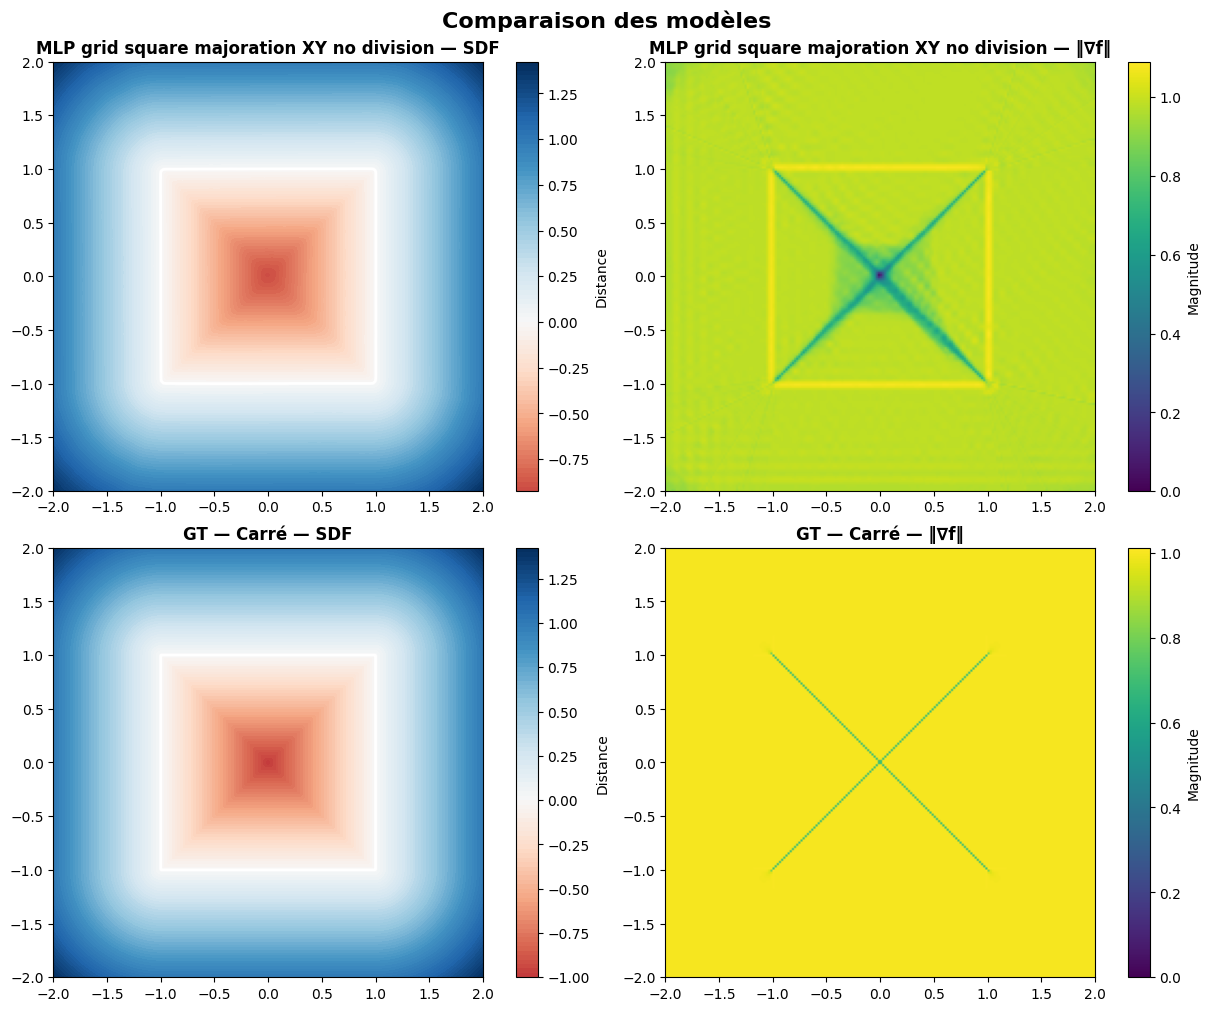

In [57]:
visualize_comparison(
    models=[
        # (sll_simple, "SLL simple"),
        # (mlp_grid_square_majoration_XY, "MLP grid square majoration XY "),
        # (mlp_grid_square_proj_all, "MLP grid square majoration XY with project_all"),
        (mlp_grid_square_nodiv, "MLP grid square majoration XY no division"),
    ],
    sdf_funcs=[
        (lambda x, y: square(x, y, 1.0),   "Carré"),
    ]
)

- With layer division

In [69]:
mlp_grid_square_layerdivLast, hist = train_Lipschitz_param(
    LipschitzParam(
        resolution=64,
        feature_dim=16,
        k=128,
        n_layers=20,
        add_positions=True,
        project_all=False,
        constant_majoration=True,
        divide=False,
        sll_divide = True
    ),
    lambda x, y: square(x, y, 1.0),
    nb_samples=100_000,
    lr=1e-3,
    nb_epochs=8000,
    m=0.01, 
    parallel=True,
    majoration=True,
    lambda_schedule={
        0:    10,
        500:  30,
        1000: 60,
        2000: 100,
        3000: 200,
        4000: 400,
        5000: 800,
    }
)

Using 2 GPUs for training.
  → λ = 20
Epoch     0 | loss=0.01532 | Max Batch L_enc=0.1559 | Max Batch L_pre = 1.0121 | Total L (theoretical) : 0.7156
  → λ = 60
Epoch   800 | loss=-0.00601 | Max Batch L_enc=1.1510 | Max Batch L_pre = 1.5247 | Total L (theoretical) : 1.0781
  → λ = 120
Epoch  1600 | loss=-0.00298 | Max Batch L_enc=1.1535 | Max Batch L_pre = 1.5266 | Total L (theoretical) : 1.0795
  → λ = 200
Epoch  2400 | loss=-0.00176 | Max Batch L_enc=1.1540 | Max Batch L_pre = 1.5270 | Total L (theoretical) : 1.0798
  → λ = 400
Epoch  3200 | loss=-0.00084 | Max Batch L_enc=1.1485 | Max Batch L_pre = 1.5229 | Total L (theoretical) : 1.0768
  → λ = 800
Epoch  4000 | loss=-0.00040 | Max Batch L_enc=1.1667 | Max Batch L_pre = 1.5366 | Total L (theoretical) : 1.0865
Epoch  4800 | loss=-0.00039 | Max Batch L_enc=1.1556 | Max Batch L_pre = 1.5282 | Total L (theoretical) : 1.0806
  → λ = 1600
Epoch  5600 | loss=-0.00016 | Max Batch L_enc=1.1526 | Max Batch L_pre = 1.5260 | Total L (theoretic

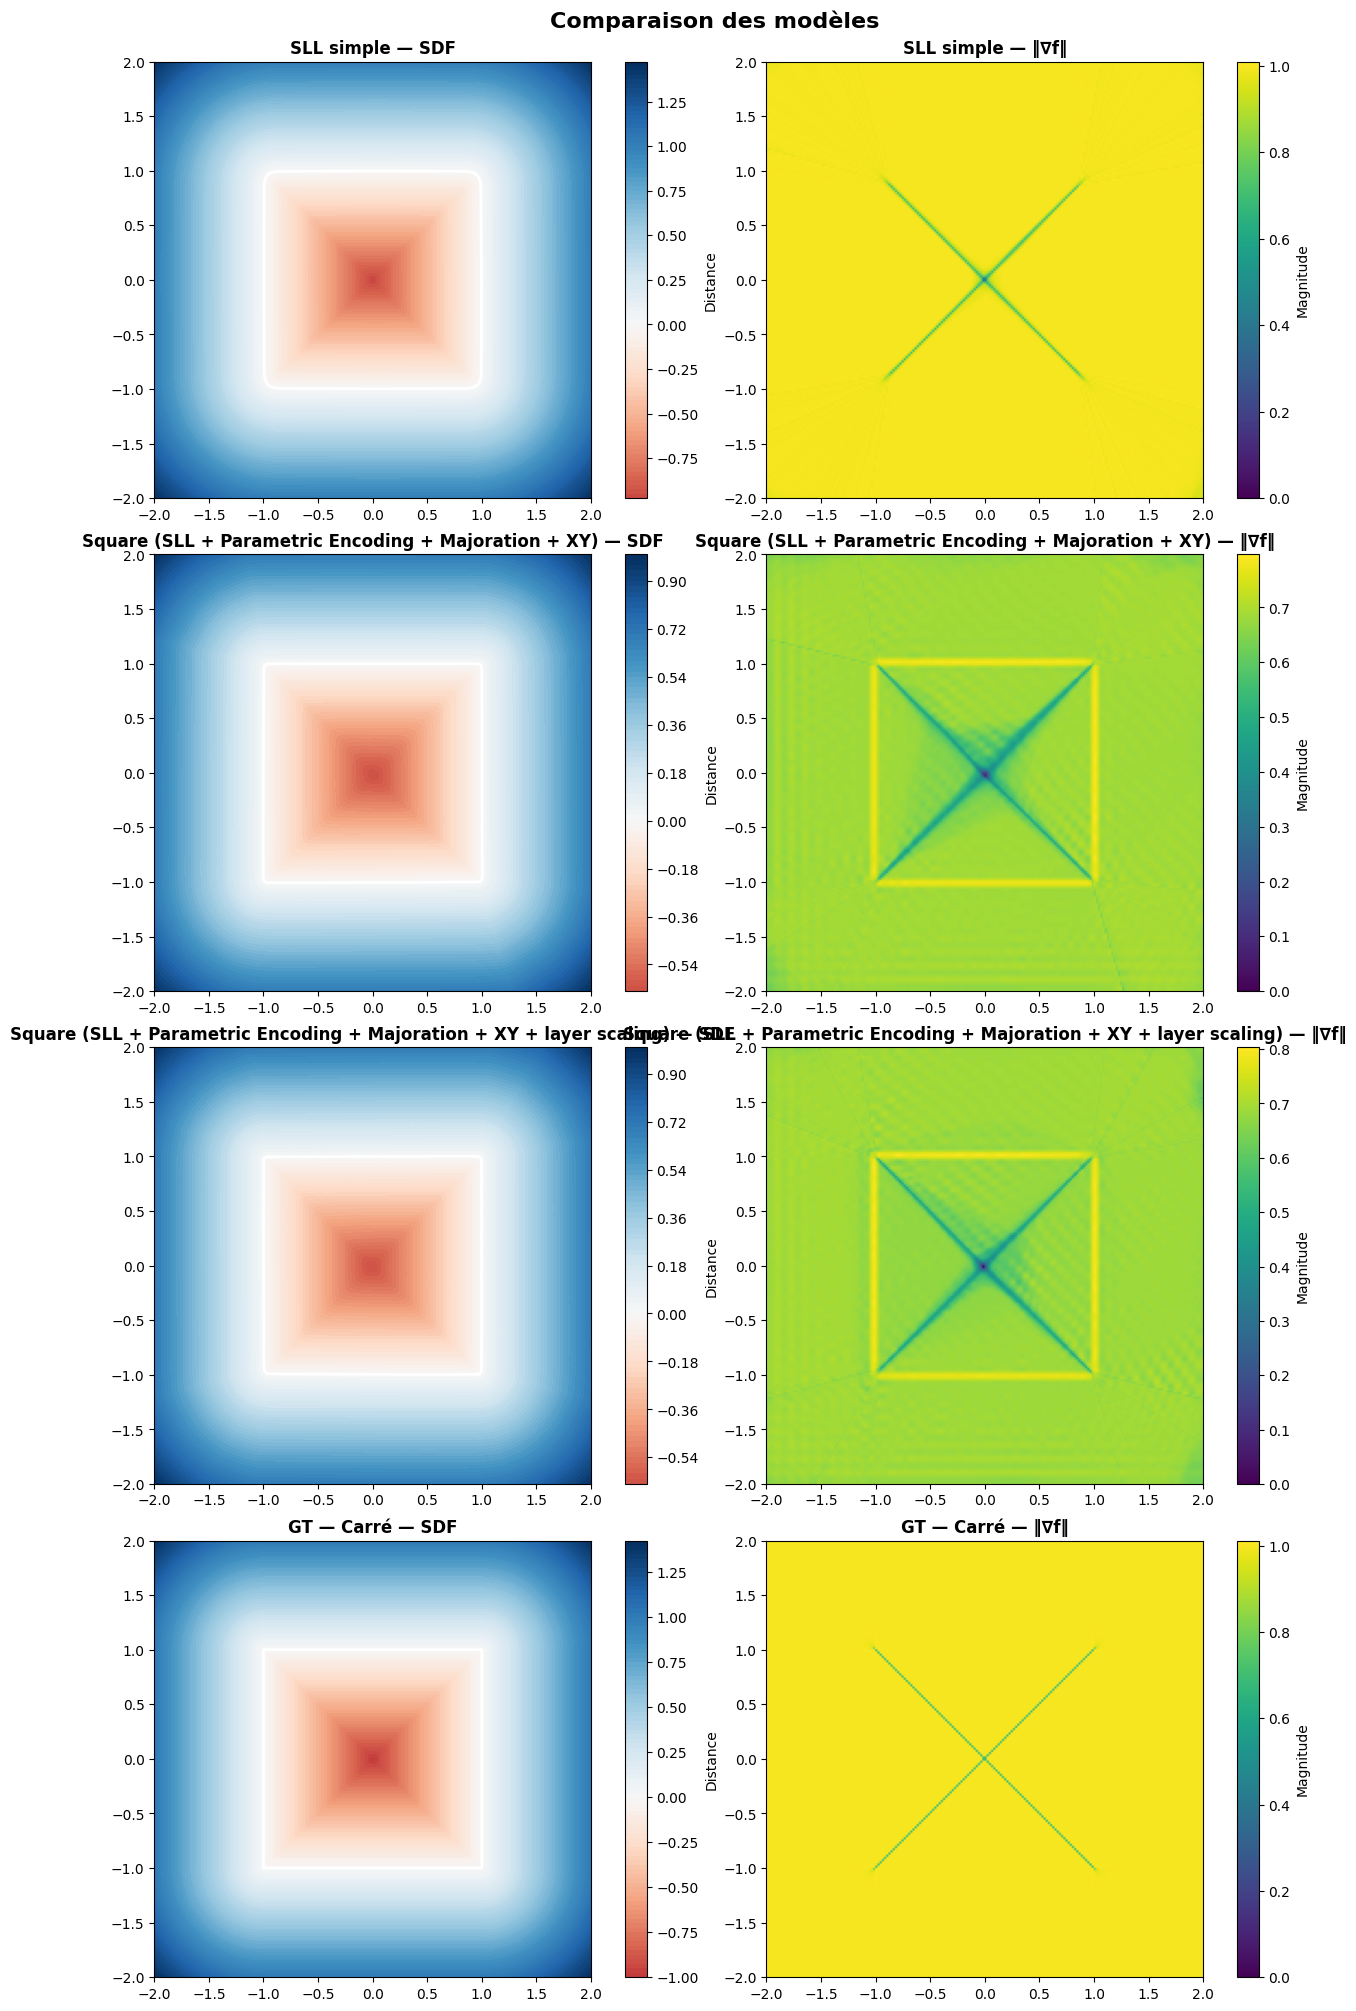

In [70]:
visualize_comparison(
    models=[(sll_simple, "SLL simple"),
            (mlp_grid_square_majoration_XY, "Square (SLL + Parametric Encoding + Majoration + XY)"),
            (mlp_grid_square_layerdivLast, "Square (SLL + Parametric Encoding + Majoration + XY + layer scaling)"),
            ],
    sdf_funcs=[(lambda x, y: square(x, y, 1.0), "Carré")]
)

### Final visualization

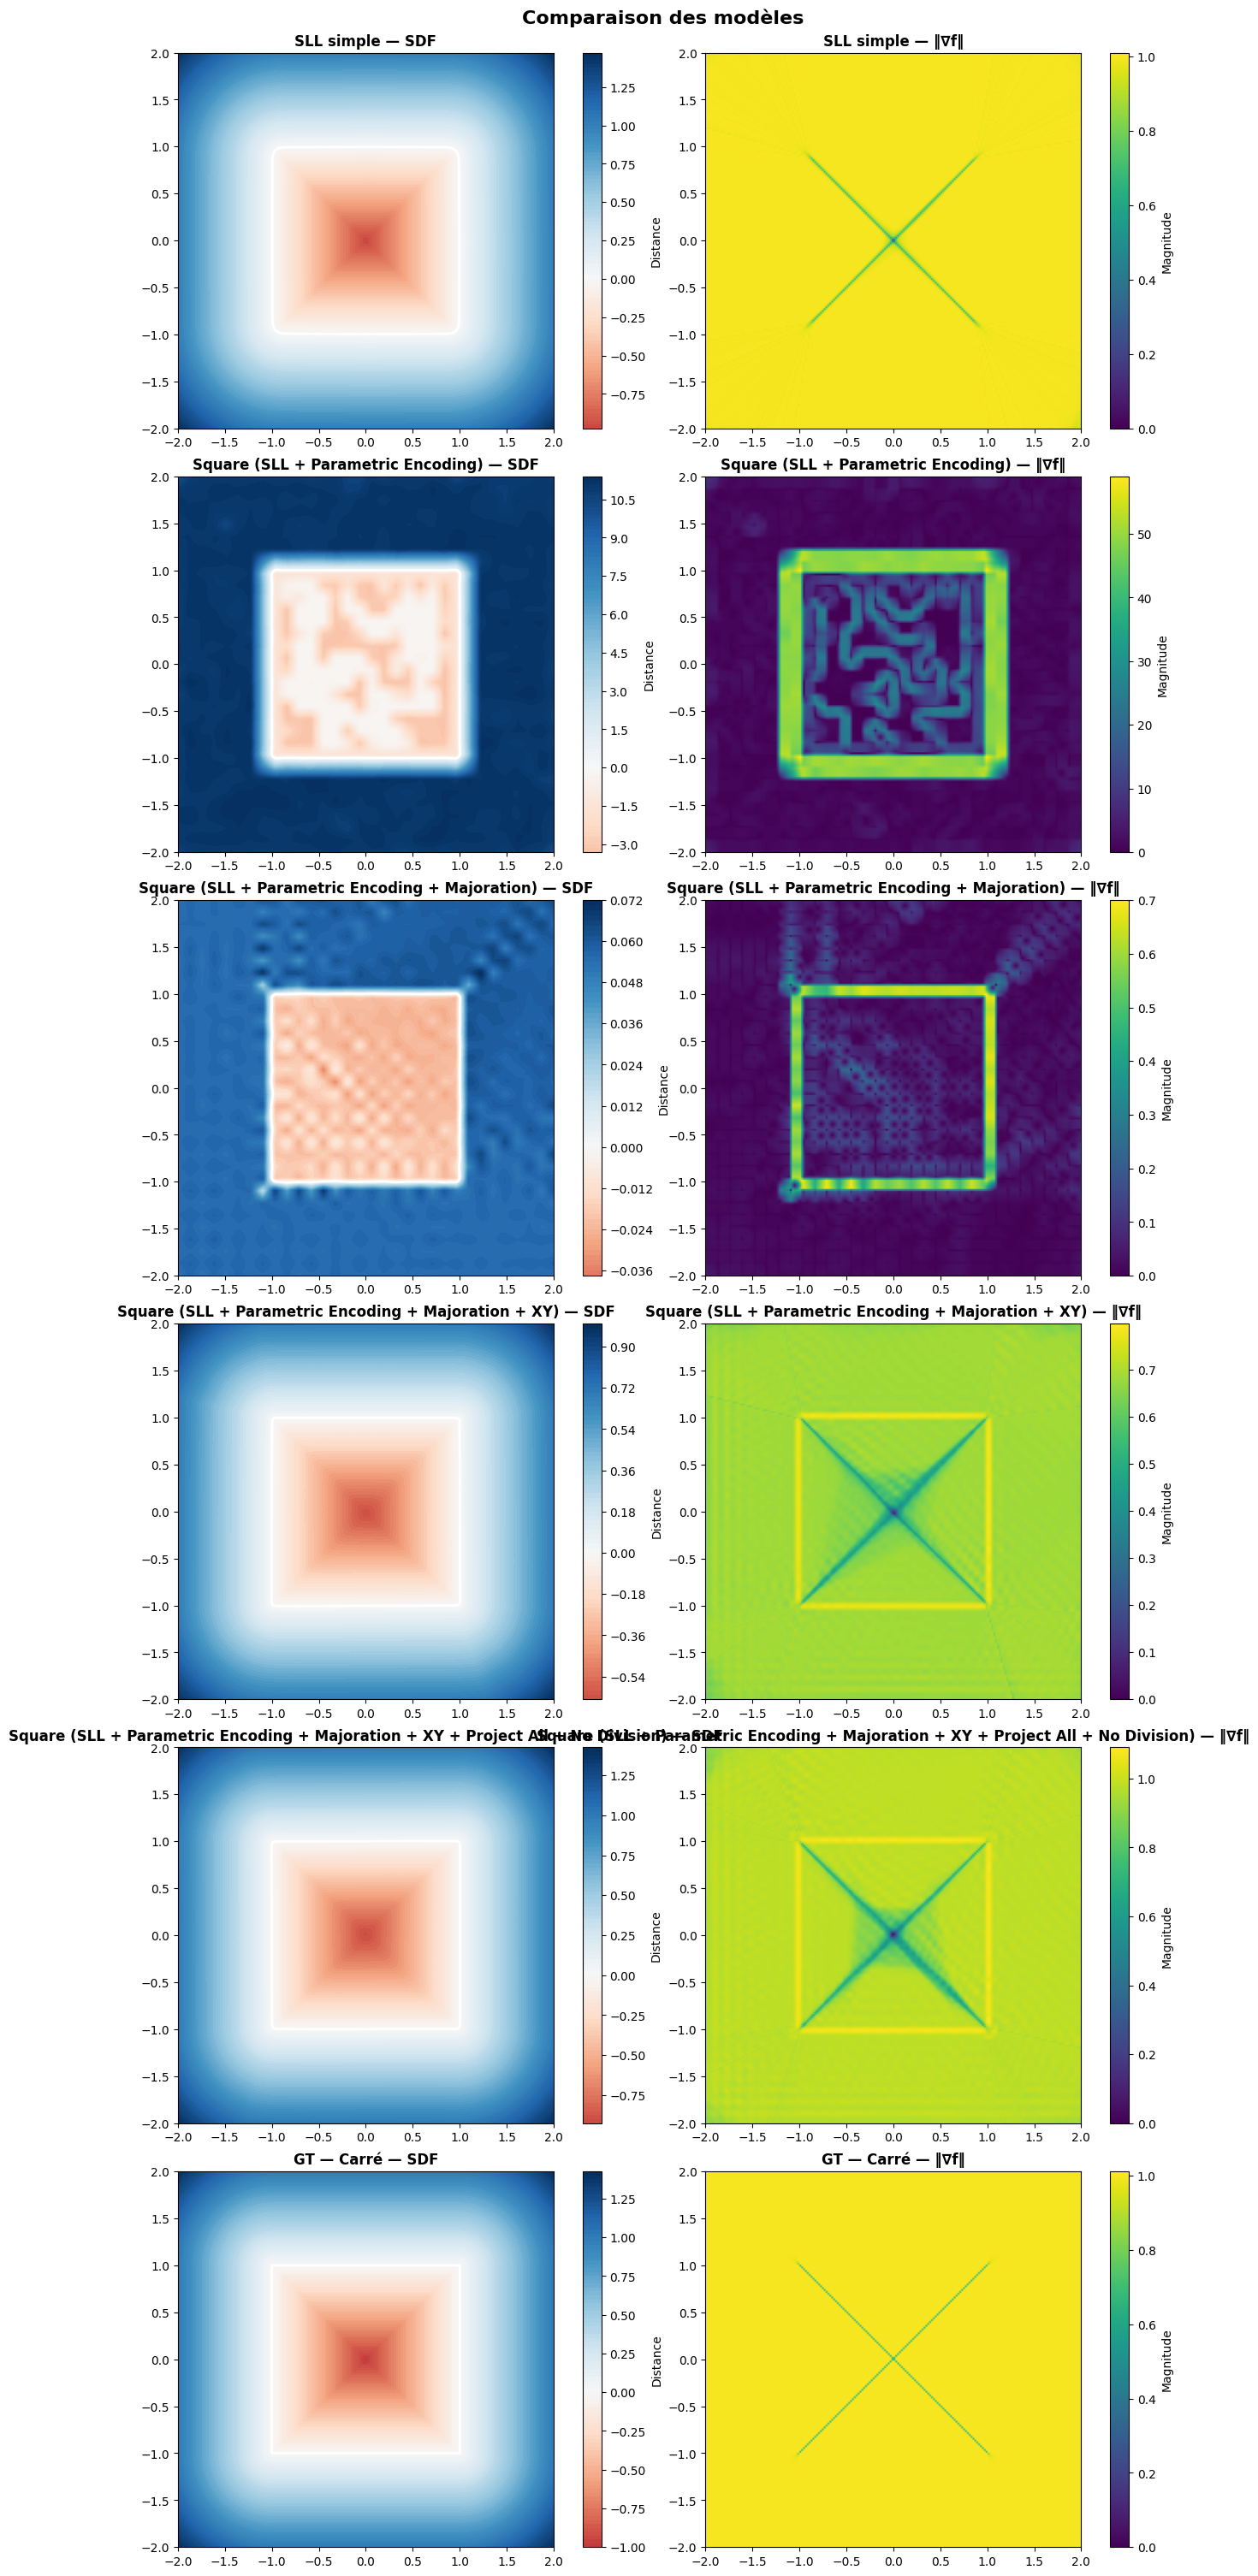

In [56]:
visualize_comparison(
    models=[(sll_simple, "SLL simple"),
            (mlp_grid_square, "Square (SLL + Parametric Encoding)"),
            (mlp_grid_square_majoration, "Square (SLL + Parametric Encoding + Majoration)"),
            (mlp_grid_square_majoration_XY, "Square (SLL + Parametric Encoding + Majoration + XY)"),
            (mlp_grid_square_nodiv, "Square (SLL + Parametric Encoding + Majoration + XY + Project All + No Division)"),
            ],
    sdf_funcs=[(lambda x, y: square(x, y, 1.0), "Carré")]
)

## Courbures 2D

### Definition

In [60]:
def curvature_og(f, x):
    x = x.clone().requires_grad_(True)
    y = f(x).squeeze(-1)

    gradf = torch.autograd.grad(y.sum(), x, create_graph=True)[0]
    dxf, dyf = gradf[:, 0], gradf[:, 1]

    grad_dxf = torch.autograd.grad(dxf.sum(), x, create_graph=True)[0]
    grad_dyf = torch.autograd.grad(dyf.sum(), x, create_graph=True)[0]

    dxxf = grad_dxf[:, 0]
    dxyf = grad_dxf[:, 1]          # == grad_dyf[:, 0] par Schwarz
    dyyf = grad_dyf[:, 1]

    norm_gradf = (dxf**2 + dyf**2).clamp_min(1e-12).sqrt()
    curvature = (dxxf*dyf**2 + dyyf*dxf**2 - 2*dxf*dyf*dxyf) / norm_gradf**3
    return curvature


def _eval_field(f, x):
    """
    Évalue f en x (N, 2), en acceptant deux conventions :
      - f(x)     : style "modèle" (nn.Module ou fonction prenant les points empilés)
      - f(x, y)  : style "ground truth" (ex: lambda x, y: square(x, y, 1.0))
    On essaie d'abord le style modèle ; une TypeError (mauvaise arité) fait
    retomber sur le style (x, y). Les autres exceptions (bug réel dans f)
    continuent de remonter normalement.
    """
    try:
        out = f(x)
    except TypeError:
        out = f(x[:, 0], x[:, 1])
    if out.dim() > 1:
        out = out.squeeze(-1)
    return out


def curvature(f, x):
    x = x.clone().requires_grad_(True)
    y = _eval_field(f, x)
    gradf = torch.autograd.grad(y.sum(), x, create_graph=True)[0]
    dxf, dyf = gradf[:, 0], gradf[:, 1]
    grad_dxf = torch.autograd.grad(dxf.sum(), x, create_graph=True)[0]
    grad_dyf = torch.autograd.grad(dyf.sum(), x, create_graph=True)[0]
    dxxf = grad_dxf[:, 0]
    dxyf = grad_dxf[:, 1]          # == grad_dyf[:, 0] par Schwarz
    dyyf = grad_dyf[:, 1]
    norm_gradf = (dxf**2 + dyf**2).clamp_min(1e-12).sqrt()
    curvature = (dxxf*dyf**2 + dyyf*dxf**2 - 2*dxf*dyf*dxyf) / norm_gradf**3
    return curvature


### Visualization

In [61]:

def plot_curvature_on_surface(f, domain=(-2, 2), resolution=200, clip=None, device='cpu'):
    lin = torch.linspace(domain[0], domain[1], resolution, device=device)
    gx, gy = torch.meshgrid(lin, lin, indexing='xy')
    pts = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=-1)
    with torch.no_grad():
        f_val = _eval_field(f, pts).reshape(resolution, resolution).cpu().numpy()
    tmp_fig = plt.figure()
    cs = plt.contour(gx.cpu().numpy(), gy.cpu().numpy(), f_val, levels=[0])
    plt.close(tmp_fig)
    segments = cs.allsegs[0]
    if not segments:
        print("Aucune surface trouvée dans ce domaine (f=0 jamais atteint).")
        return
    # 1ere passe : calcule kappa partout, pour caler l'echelle sur les vraies valeurs
    kappas = [curvature(f, torch.tensor(seg, dtype=torch.float32, device=device)).detach().cpu().numpy()
              for seg in segments]
    all_kappa = np.concatenate(kappas)
    print(f"courbure sur la surface : min={all_kappa.min():.4f}  max={all_kappa.max():.4f}")
    vmax = clip if clip is not None else max(np.abs(all_kappa).max(), 1e-6)
    norm = plt.Normalize(-vmax, vmax)
    fig, ax = plt.subplots(figsize=(6, 6))
    for seg, kappa in zip(segments, kappas):
        pts2 = seg.reshape(-1, 1, 2)
        line_segs = np.concatenate([pts2[:-1], pts2[1:]], axis=1)
        lc = LineCollection(line_segs, cmap='RdBu', norm=norm)
        lc.set_array(kappa[:-1])
        lc.set_linewidth(3)
        ax.add_collection(lc)
    sm = plt.cm.ScalarMappable(cmap='RdBu', norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=f'courbure κ (échelle auto ±{vmax:.3g})')
    ax.set_xlim(domain); ax.set_ylim(domain)
    ax.set_aspect('equal')
    ax.set_title('Courbure le long de la surface (f=0)')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()

courbure sur la surface : min=nan  max=nan


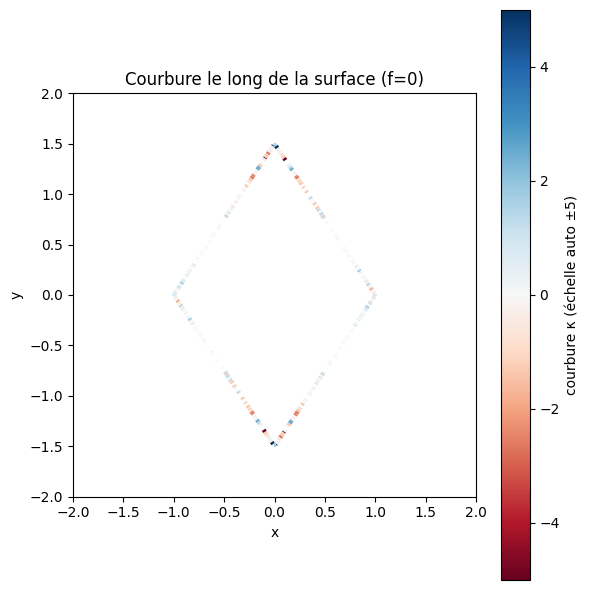

In [63]:
plot_curvature_on_surface(lambda x, y: sdRhombus(x, y, 1.0), domain=(-2, 2), resolution=200, clip=5.0, device='cuda:0')